El modelo depredador-presa es un modelo de simulación poblacional similar al modelo SIR, en este caso con 2 poblaciones que coexisten en un mismo entorno donde uno se alimenta de el otro (predador) y el otro crece en base a la población de los depredadores (presa): [ED del modelo depredador-presa](\resources\ED_DP.png).

En este caso D es la población de depredadores, P la población de presas. Nu, mu, alpha y delta son constantes de ajuste del sistema.

Preparamos las condiciones iniciales y características del sistema a simular.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#Constantes del modelo depredador-presa
nu = 0.8 #Tasa de crecimiento de presas
mu = 0.05 #Tasa de caza de presas por depredadores
delta = 1.2 #Tasa de mortalidad de depredadores
alpha = 0.02 #Tasa de reproducción de depredadores por consumo de presas
P0 = 60 #Población inicial de presas
D0 = 20 #Pobalción inicial de depredadores
dias = 300 #Tiempo de simulación

Calculamos el cambio en el tiempo de cada población.

In [2]:
#Sistema de ED del modelo depredador-presa
def DP(P, D, nu, mu, delta, alpha):
    dP_dt = P * (nu - (mu * D))
    dD_dt = D * ((alpha * P) - delta)
    return dP_dt, dD_dt

Simulamos el sistema durante el tiempo designado.

In [3]:
#Simulación del sistema de ED DP
def simu_DP(P0, D0, nu, mu, delta, alpha, dias):
    dt = 0.01  # Paso de tiempo
    pasos_totales = int(dias / dt)
    P = np.zeros(pasos_totales)
    D = np.zeros(pasos_totales)
    
    P[0] = P0
    D[0] = D0
    
    for t in range(1, pasos_totales):
        dP_dt, dD_dt = DP(P[t-1], D[t-1], nu, mu, delta, alpha)
        P[t] = P[t-1] + dP_dt * dt
        D[t] = D[t-1] + dD_dt * dt
        
        # Acotamos la población, ya que no hay poblaciones negativas
        P[t] = max(P[t], 0)
        D[t] = max(D[t], 0)
        
    return P, D

Finalmente obtenemos P y D como una evolución temporal continua bajo el sistema de ED del modelo DP.

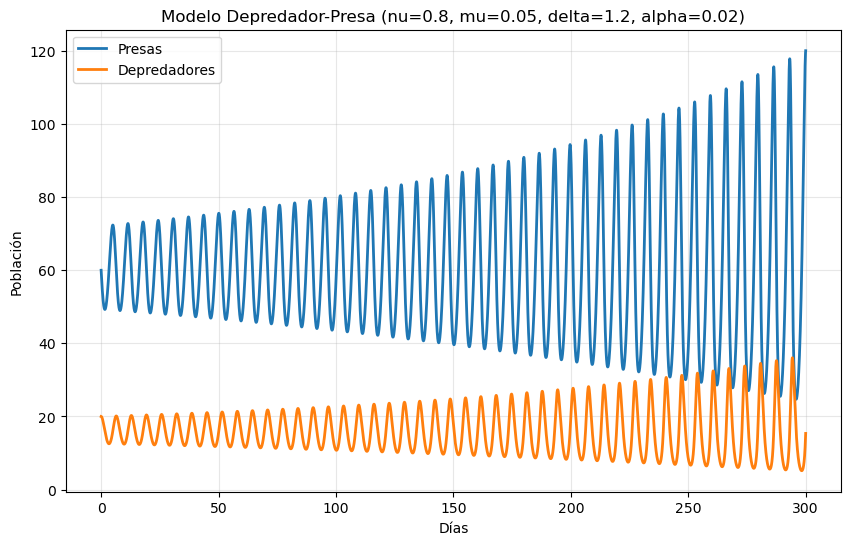

In [4]:
#Simulación
P, D = simu_DP(P0, D0, nu, mu, delta, alpha, dias)

# Designamos el avance temporal ajustado a la cantidad de dias de simulación
dt = 0.01
tiempo = np.arange(0, dias, dt)

#Gráfica de resultados
plt.figure(figsize=(10,6))
plt.plot(tiempo, P, label='Presas', linewidth=2)
plt.plot(tiempo, D, label='Depredadores', linewidth=2)
plt.xlabel('Días')
plt.ylabel('Población')
plt.title('Modelo Depredador-Presa (nu={}, mu={}, delta={}, alpha={})'.format(nu, mu, delta, alpha))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Catalogaremos los modelados en base a nu, mu, delta y alpha de la forma output_DP(nu-mu-delta-aplha).png tomando como ejemplo el modelo basico sería output_DP(8-01-6-01).png

Referencias:

-[Análisis del sistema de ED DP](https://watermark02.silverchair.com/3-1-3.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAAA00wggNJBgkqhkiG9w0BBwagggM6MIIDNgIBADCCAy8GCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMjI8dQeXLYeii6zQ0AgEQgIIDALUk1kiAzB854XhXeHfurxMKL-Mw66eHcSWv_0_PwzGKQcefrlWt56jkwtNXTsmBCbEUf3rShiFZ3uY-ML7byI3h-wgxUwW-Ud8WZomExradv45BrYCjoScbgRWuIlOhUh9PGE8rlZ-y2_qrgCkn538Nb1MJfiFtFuc35-PrgK4EcY2ZtMDExUS-HKk3344VwVyggcjHtAGHPKBGLwe-UV4_vmWUskVu105OfCkKoPatmWs0rJ6m5WItWz9TPXfb2kDsLvG3_5L-hf9LVx8iU3mOVHhG7_Rd2V1RX7sn6rwMbd4fDcEXrJVmd7222-UzT7_qe-v4Q-snG-AVV4nqvSW4RGkebbhQmWeI8RJk7bo-wnD1qwbz9fqkMHjaX62HJ7hCeg7kUkdQpGbVT_tj3Ysq51UuG4f9maNpPFvGeexz2r1SjwS2PMgPWZRbHr4AC0752jKG3q9f-EZNYI-wH1wR_0SAuuDz4XcLH438jWvBntIP3wdV7uvOfBltT9EGka3BpN7vnh0fR96dmO_R4OprvQEC80MxNQL0OlT-y_EQHNEPWaAUng9W9i1If5XDAzT8IQBQxgtiRmRNepkuSVjoJcRpxWDsuJpyQ9NW13kIXevecKb4u8RfImoID0QSFX74XBhmOr1wEMr71CaWVXBl4b3utsY7lQ1XvWYKGNjMdo8DCL8u777lg4U0vjJF2WkJxSetDcK3cvp8s_DlEsUSjVSjUIAZQy5N7CAAJemJFmDE_6jBqaCFrlm_UVl2zVn61uy_iTaoUV9DzbGyQKpdHVFMjCAx93FB1ljLj2cmMj5Ve7vhEYqhILgWiNAiSjL9gZ50Fce2mny__cdj3nZ6vWvGS-h2z4VRoCTuxzbfVpqp8S7c0MRQ5BnSGKf1kkT0wLMUcEAsqI__j1R0fLnNGTx-MPswKq63ziq_pYMS44jOXr6aJHVqvyA4jLW4HAaESJsjKJS10UChqD3Ixaze3VruM8H-jgI-aoLpXZ-uT9TsZJM2WNqIPOs0udhJ5w)

-[Avances en los modelos DP](https://www.mdpi.com/2227-7390/9/15/1783)
